In [1]:
# Figure 7

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':15})
plt.rc('mathtext',**{'default':'regular'})
plt.rc('axes',linewidth=2)
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [5]:

dss = xr.open_dataset('/work/Chiung-Yin.Chang/CPT_Review/ocean_annual_z.static.nc')
yh = dss.yh.values

arch= '/work/Chiung-Yin.Chang/OM4/Review-data/'
fK_ref=np.load(arch+'REF_BTBC_KE_fractions.npz')
fK_BS=np.load(arch+'BS_BTBC_KE_fractions.npz')
fK_BSV=np.load(arch+'BSV_BTBC_KE_fractions.npz')

fE_ref=np.load(arch+'REF_ssh_variance.npz')
fE_BS=np.load(arch+'BS_ssh_variance.npz')
fE_BSV=np.load(arch+'BSV_ssh_variance.npz')


/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:12: RuntimeWarning: Mean of empty slice
  var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:16: RuntimeWarning: Mean of empty slice
  var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:20: RuntimeWarning: Mean of empty slice
  var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:26: RuntimeWarning: Mean of empty slice
  var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:29: RuntimeWarning: Mean of empty slice
  var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429240/1386447019.py:32: RuntimeWa

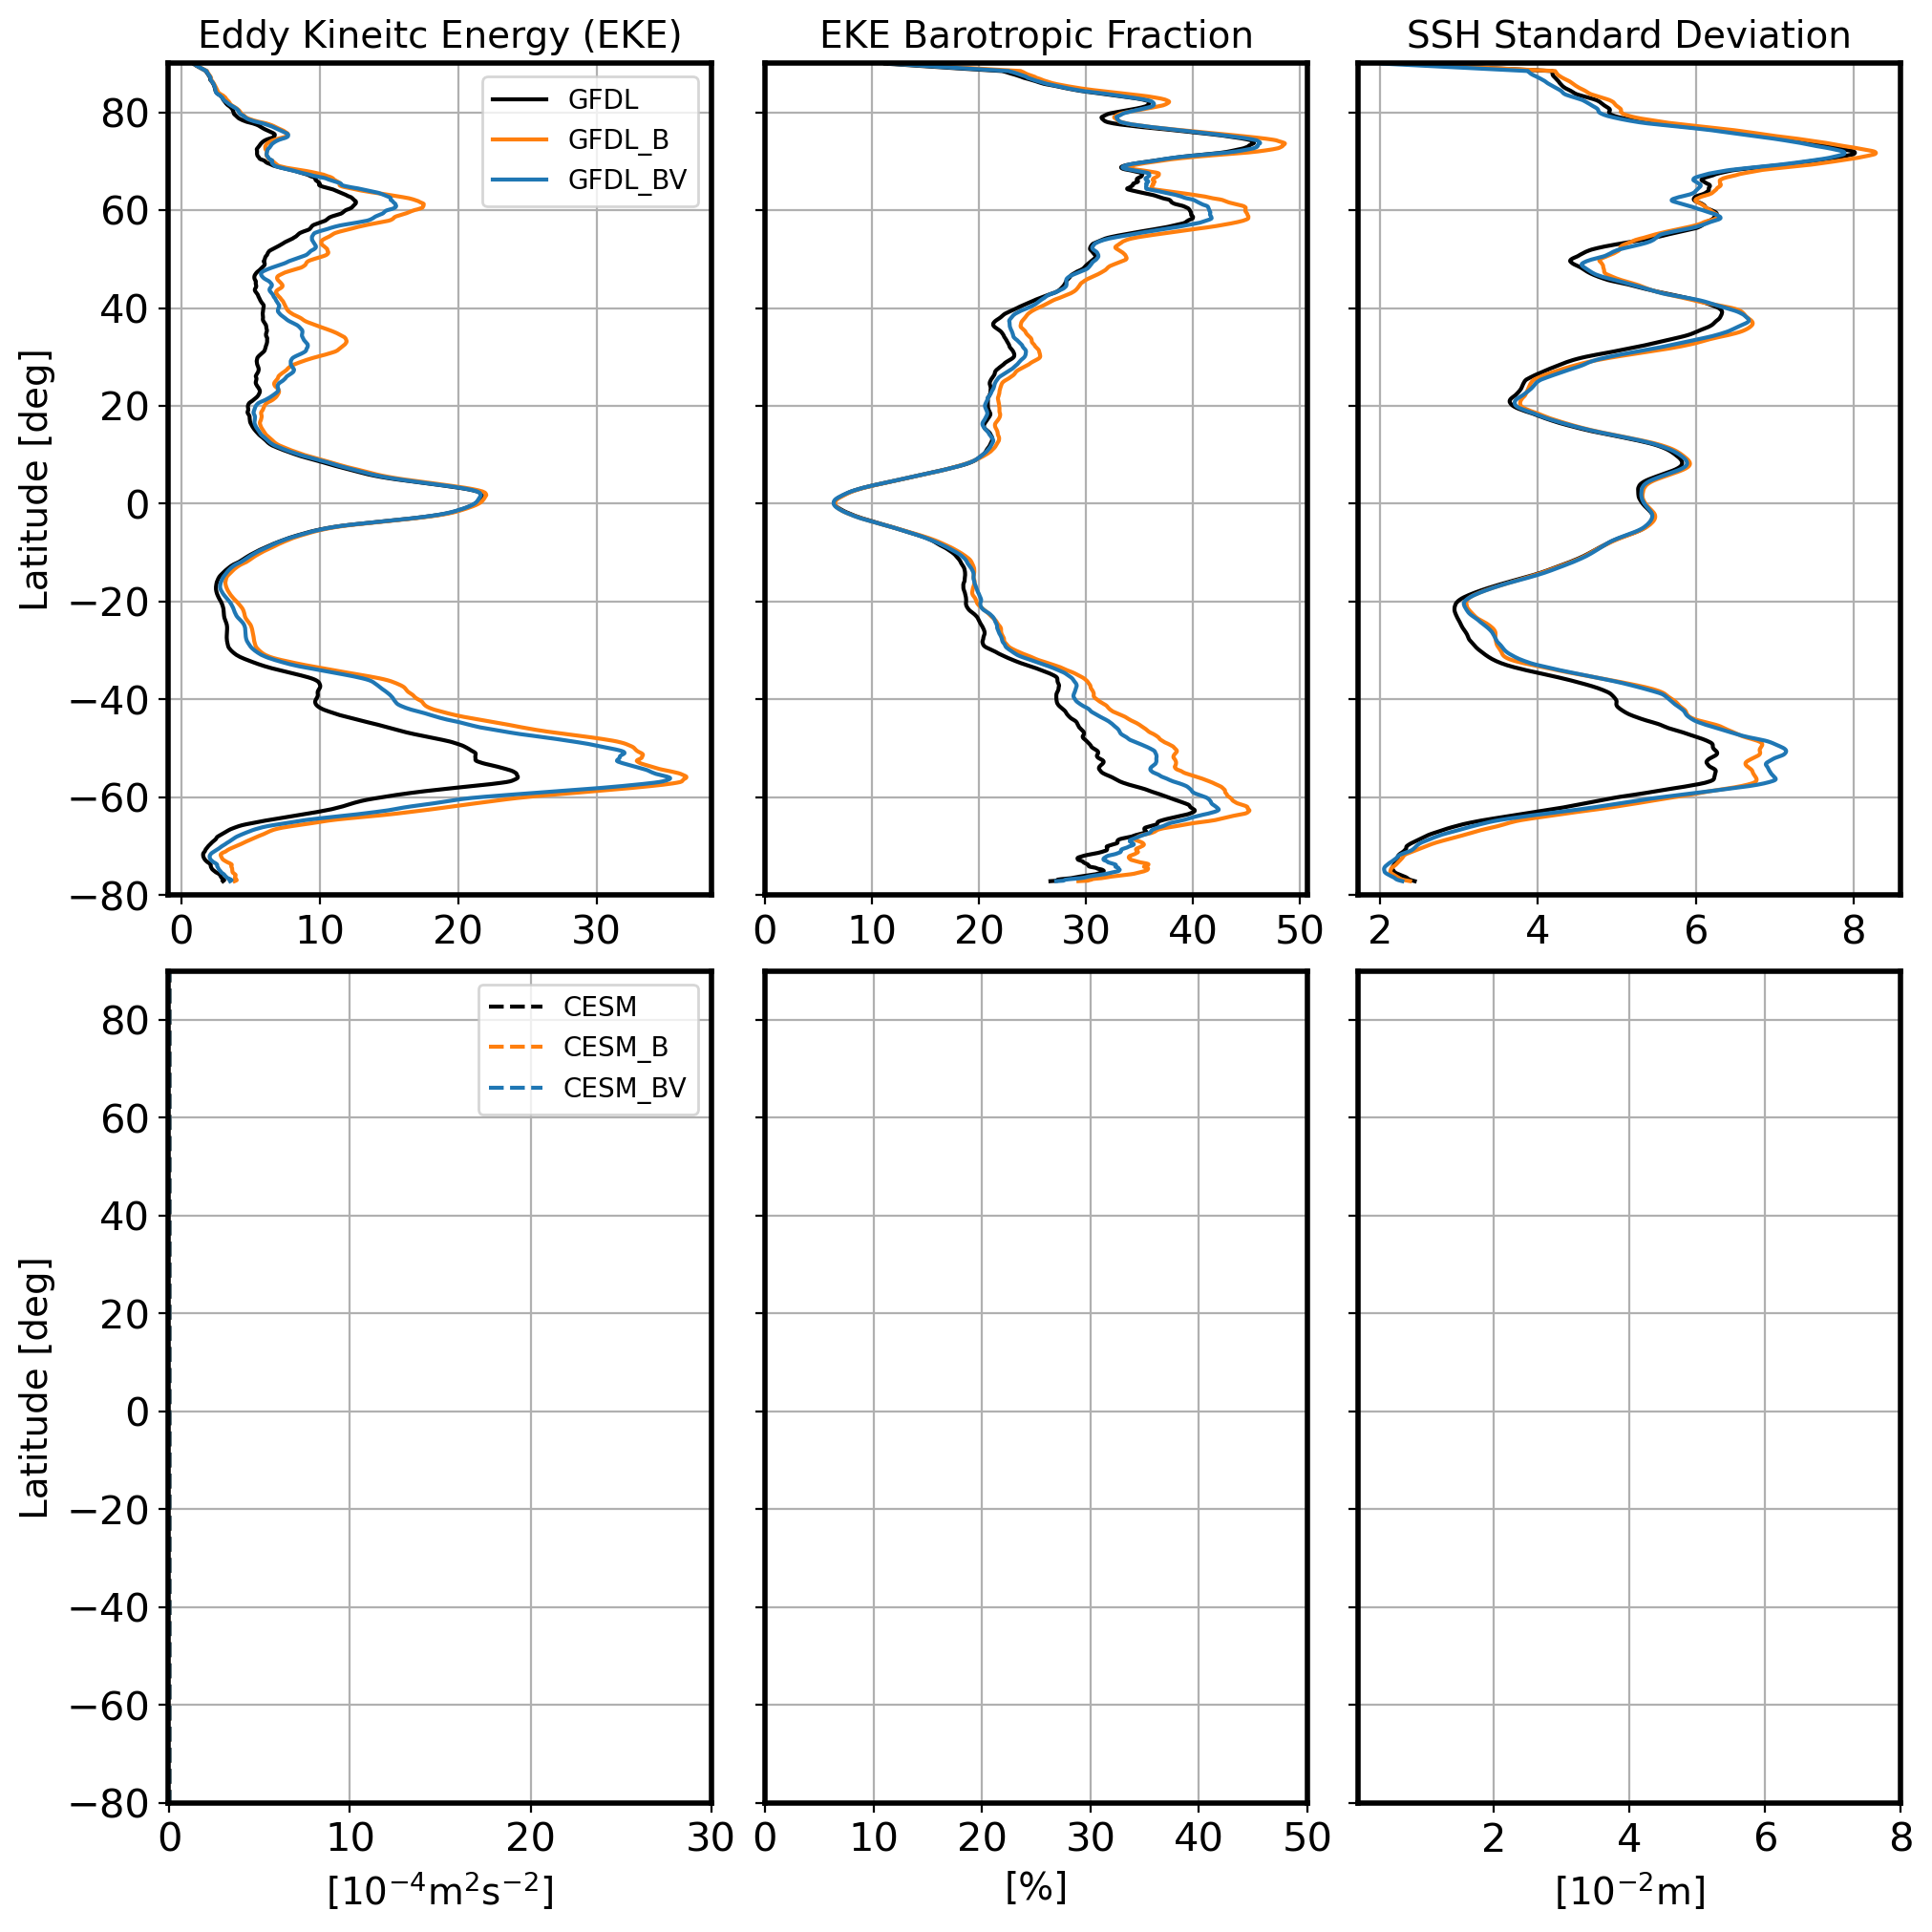

In [26]:

#For the convolution window use N=240 for 1/32 deg.; N=120 for 1/16deg.; N=60 for 1/8deg.; and N=30 for 1/4deg.
window=30

fig, axs = plt.subplots(2, 3, sharey=True, constrained_layout=True, figsize=(10,10))

## GFDL:

for i, ax in enumerate(axs[0,:]):
    if i==0:
        f=fK_ref
        var=f['KE_eddy_BT']+f['KE_eddy_BC']#+f['KE_mean_BT']+f['KE_mean_BC']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(var*1e4,yh,color='black', linewidth=1.5, label='GFDL')
        f=fK_BS
        var=f['KE_eddy_BT']+f['KE_eddy_BC']#+f['KE_mean_BT']+f['KE_mean_BC']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(var*1e4,yh,color='tab:orange', linewidth=1.5, label='GFDL_B')
        f=fK_BSV
        var=f['KE_eddy_BT']+f['KE_eddy_BC']#+f['KE_mean_BT']+f['KE_mean_BC']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(var*1e4,yh,color='tab:blue', linewidth=1.5, label='GFDL_BV')
        ax.set_title('Eddy Kineitc Energy (EKE)',fontsize=14)
        
    elif i==1:
        var=fK_ref['fraction_BT_eddy']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='black',linewidth=1.5)
        var=fK_BS['fraction_BT_eddy']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='tab:orange',linewidth=1.5)
        var=fK_BSV['fraction_BT_eddy']
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='tab:blue',linewidth=1.5)
        ax.set_xticks(np.arange(0,51,10))
        ax.set_title('EKE Barotropic Fraction',fontsize=14)
    else:
        var=np.sqrt(fE_ref['ssh_v'])
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='black',linewidth=1.5)
        
        var=np.sqrt(fE_BS['ssh_v'])
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='tab:orange',linewidth=1.5)
        
        var=np.sqrt(fE_BSV['ssh_v'])
        var=np.convolve(np.nanmean(var,axis=-1), np.ones((window,))/window, mode='same')
        ax.plot(100*var,yh,'-',color='tab:blue',linewidth=1.5)
        ax.set_title('SSH Standard Deviation',fontsize=14)
    
    ax.set_ylim([-80,90]);
    
    ax.grid()

axs[0,0].set_ylabel('Latitude [deg]',fontsize=14);
axs[0,0].legend(loc='upper right',ncol=1,fontsize=10)


## CESM:


for i, ax in enumerate(axs[1,:]):
    if i==0:
        ax.plot(yh*0,yh,color='black', linestyle='--', linewidth=1.5, label='CESM')
        ax.plot(yh*0,yh,color='tab:orange', linestyle='--', linewidth=1.5, label='CESM_B')
        ax.plot(yh*0,yh,color='tab:blue', linestyle='--', linewidth=1.5, label='CESM_BV')
       
        ax.set_xticks(np.arange(0,40,10))
        ax.set_xlabel('[$10^{-4}m^2s^{-2}$]',fontsize=14)
        ax.grid()
    elif i==1:
        ax.set_xticks(np.arange(0,60,10))
        ax.set_xlabel('[%]',fontsize=14)
        ax.grid()
    elif i==2:
        ax.set_xticks(np.arange(2,10,2))
        ax.set_xlabel('[$10^{-2}m$]',fontsize=14)
        ax.grid()


axs[1,0].set_ylabel('Latitude [deg]',fontsize=14);
axs[1,0].legend(loc='upper right',ncol=1,fontsize=10)

fig.savefig('Figure_CPT_review/GCM_energetics.pdf',dpi=800)
# plt.tight_layout()
# plt.show()